In [1]:
#Load necessary modules

import astropy
import astropy.io
from astropy.io import fits
import numpy as np
import math
import matplotlib.pyplot as plt
from astropy import modeling
from astropy.convolution import convolve, Gaussian2DKernel, Moffat2DKernel
import random 
from random import uniform

In [2]:
#Load the FITS file for the image

hdu = astropy.io.fits.open(r"C:\Users\jacob\AstronomyResearchStuff\e20191014_00130000215_dp_st_tl_neb_90_30.fit")

In [ ]:
hdu[1].header

In [3]:
#Load the image data and use the shape function to check the right data was retrieved

data = hdu[1].data
print(np.shape(data))

(15684, 12794)


In [7]:
#Turn the entire image into a mesh grid to allow for inserting the galaxy sources

#Get rows and columns that are the same lengths as the image shape

xLength = data.shape[1]
yLength = data.shape[0]

#Create linspaces based on the shape of the data

xSpace = np.linspace(0, (xLength-1), xLength)
ySpace = np.linspace(0, (yLength-1), yLength)

#Create a blank image mesh grid based upon the two lengths

xField, yField = np.meshgrid(xSpace, ySpace)

imageMesh = 0*xField + 0*yField

#Fill in the blank image mesh with the data from the image

for ii in range(0,xLength):
    if (ii % 1000) == 0:
        print(ii)
    for jj in range(0,yLength):
        imageMesh[jj,ii] = data[jj,ii]


0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000


In [8]:
#Calculate the Poisson noise at each pixel within the original image

g = 4.3
N = 1800

noise_poisson = np.sqrt(imageMesh/(g*N))

#Convert the noise back to image data units

#noise_poisson = noise_poisson/g

#Subtract the Poisson noise from the original image

noiselessOriginal = imageMesh - noise_poisson

C:\Users\jacob\AppData\Local\Temp\ipykernel_23720\1068503402.py:6: RuntimeWarning: invalid value encountered in sqrt
  noise_poisson = np.sqrt(imageMesh/(g*N))


In [23]:
#Choose a number of galaxies to inject

injectNumber = 1

#Record the shape of the data

xLength = data.shape[1]
yLength = data.shape[0]

#Create linspaces to be used to create a mesh grid
xSpace = np.linspace(0, (xLength-1), xLength)
ySpace = np.linspace(0, (yLength-1), yLength)

#Create a grid of coordinates
xField, yField = np.meshgrid(xSpace, ySpace)

#Create a blank field to add the images to 
sourceImage = 0*xField + 0*yField

center_list = []

#Generate the elliptical galaxies 
for item in range(0, injectNumber):

    #Define the center of the source
    xCenter = uniform(1, xLength)
    yCenter = uniform(1, yLength)

    deltaX = xField - xCenter
    deltaY = yField - yCenter

    #Add the source center's coordinates and type to the list

    source_coords = (xCenter, yCenter)

    center_list.append(source_coords)
    
    #Set the eccentricity of the ellipse 
    e = uniform(0,1)

    #Set the angle of rotation (in degrees)
    theta = uniform(0,360)
    
    #Compute the angle of rotation in radians
    theta = math.radians(theta)
    
    #Solve for the semimajor axis length at all points within the mesh grid
    
    a = np.sqrt((deltaX*math.cos(theta) - deltaY*math.sin(theta))**2 + (deltaY*math.cos(theta) + deltaX*math.sin(theta))**2 / (1 - e**2))
    
    #Set the variables needed to compute the surface brightness profile
    n = 3
    #I_o = 5*10**3
    I_o = 10**4
    Beta_n = 2*n - 0.324
    R_e = 25
    
    I = I_o*np.exp(-1*Beta_n*(a/R_e)**(1/n))

    #Convolve each source with a Moffat kernel 

    gamma = 3.1596
    alpha = 4.2593
    
    kernel = Moffat2DKernel(gamma, alpha)
    
    #Convolve the galaxy source data with the kernel
    
    I_convolved = convolve(I, kernel)
    
    sourceImage = sourceImage + I

#Convolve the image with a Moffat kernel

gamma = 3.1596
alpha = 4.2593

kernel = Moffat2DKernel(gamma, alpha)

#Convolve the galaxy source data with the kernel

sourceImage_convolved = convolve(sourceImage, kernel)

#Add the elliptical galaxies to the noise-subtracted image

injectImage = noiselessOriginal + sourceImage_convolved

print(center_list)

[(6550.367247152265, 5619.943797995474)]


6550.367247152265
5619.943797995474


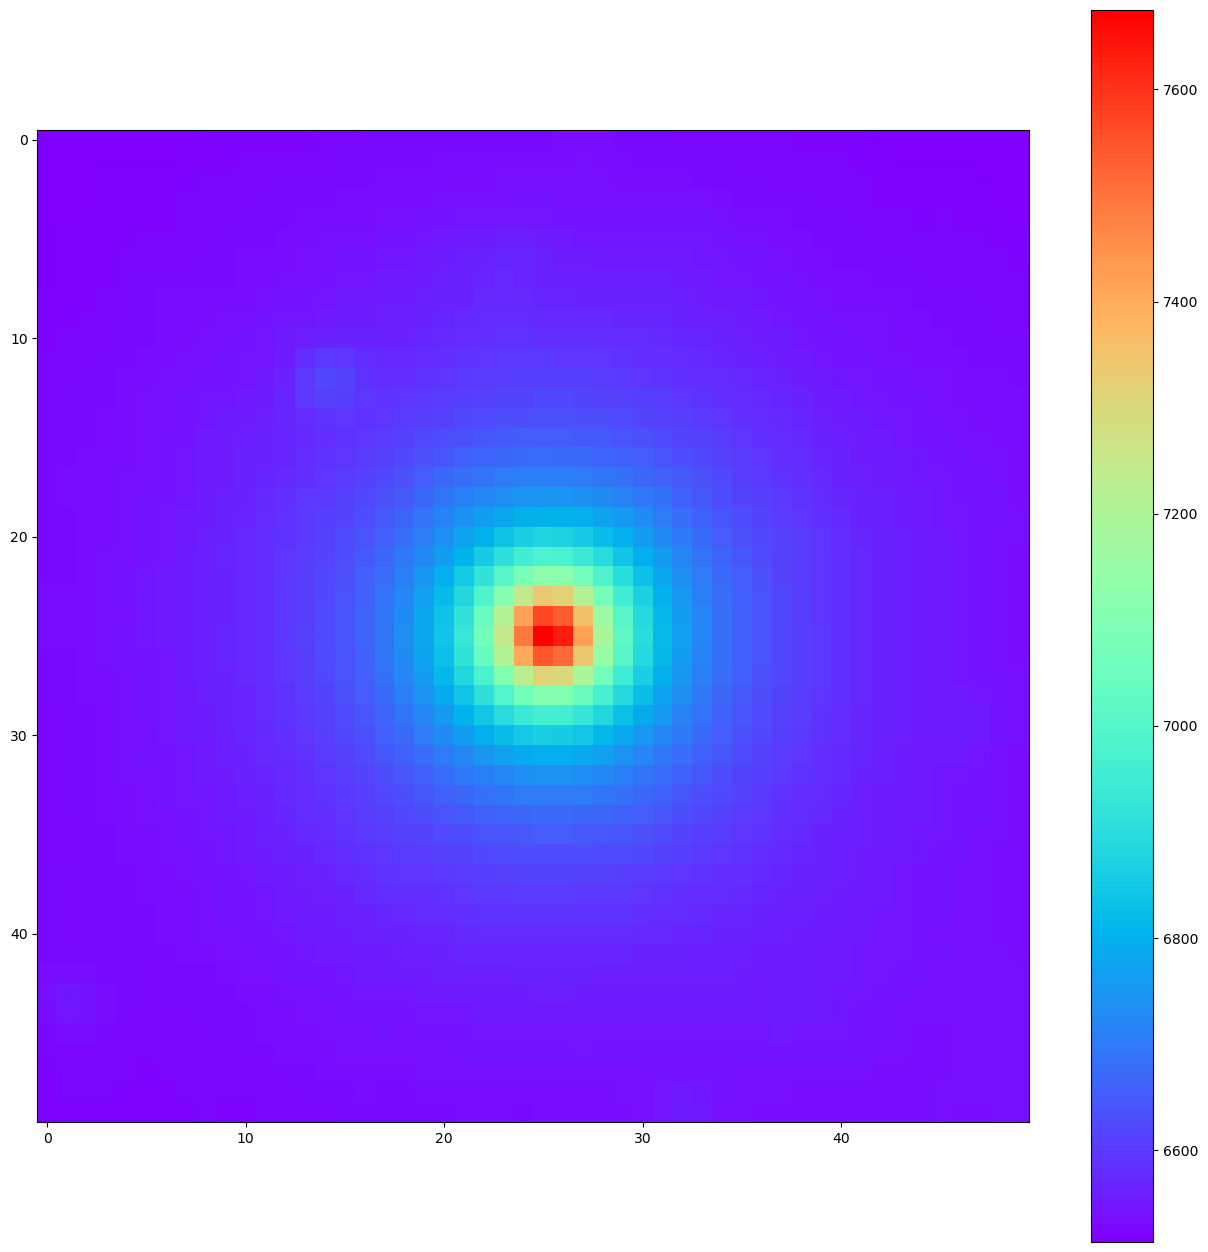

5594.943797995474
5644.943797995474
6525.367247152265
6575.367247152265


In [27]:
#View the injected image around one of the sources to make sure it was injected properly

sourceCoords = center_list[0]

xCenter = sourceCoords[0]
yCenter = sourceCoords[1]

print(xCenter)
print(yCenter)

ymin = yCenter - 25
ymax = yCenter + 25
xmin = xCenter - 25
xmax = xCenter + 25
cutout = injectImage[int(np.round(ymin)):int(np.round(ymax)), int(np.round(xmin)):int(np.round(xmax))]

plt.figure(figsize=(16, 16))
plt.imshow(cutout, cmap = 'rainbow')
plt.colorbar()
plt.show()

print(ymin)
print(ymax)
print(xmin)
print(xmax)

In [29]:
#Calculate the Poisson noise of the galaxy-injected image, and then add it to the image 

combined_Poisson_noise = np.sqrt(injectImage/(g*N))
#combined_Poisson_noise = combined_Poisson_noise / g

injectImage = injectImage + combined_Poisson_noise
print('Done!')

Done!


In [30]:
#Save the injected source image

np.save('InjectedGalaxyImage.npy', injectImage)